In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Datasets-DS_project/2015_Flight_Delays_and_Cancellations/flights.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_67581/1161913236.py:4: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Datasets-DS_project/2015_Flight_Delays_and_Cancellations/flights.csv')


In [ ]:
### Drop diverted and cancelled flights since we can't use the delay data for those
df_cleaned = df[(df['DIVERTED'] == 0) & (df['CANCELLED'] == 0)]
df_cleaned = df_cleaned.drop(columns=['DIVERTED', 'CANCELLED', 'YEAR'])

### Check for duplicate rows
duplicate_rows = df[df.duplicated()]
if (duplicate_rows.empty):
  print("no duplicated rows")
else:
  print(duplicate_rows)


### Check for empty rows that are not cancelled flights
#Filter important data that can't be missing
filtered_df = df_cleaned.iloc[:,0:22]

rows_with_missing_data = filtered_df[filtered_df.isna().any(axis=1)]

if rows_with_missing_data.empty:
    print("no missing data")
else:
    print(rows_with_missing_data)
filtered_df

no duplicated rows
no missing data


,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,...,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY
0,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,...,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0
1,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,...,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0
2,1,1,4,US,840,N171US,SFO,CLT,20,18.0,...,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0
3,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,...,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0
4,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,...,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,12,31,4,B6,688,N657JB,LAX,BOS,2359,2355.0,...,17.0,320.0,298.0,272.0,2611,749.0,4.0,819,753.0,-26.0
5819075,12,31,4,B6,745,N828JB,JFK,PSE,2359,2355.0,...,12.0,227.0,215.0,195.0,1617,427.0,3.0,446,430.0,-16.0
5819076,12,31,4,B6,1503,N913JB,JFK,SJU,2359,2350.0,...,7.0,221.0,222.0,197.0,1598,424.0,8.0,440,432.0,-8.0
5819077,12,31,4,B6,333,N527JB,MCO,SJU,2359,2353.0,...,3.0,161.0,157.0,144.0,1189,327.0,3.0,340,330.0,-10.0


In [ ]:
# 1. Filter for positive delays, THEN group and sum
delay_by_plane = df[df['Delay'] > 0].groupby('TAIL_NUM')['Delay'].sum().reset_index()

# 2. Sort to see the worst offenders
delay_by_plane = delay_by_plane.sort_values(by='Delay', ascending=False)

print(delay_by_plane.head(10))

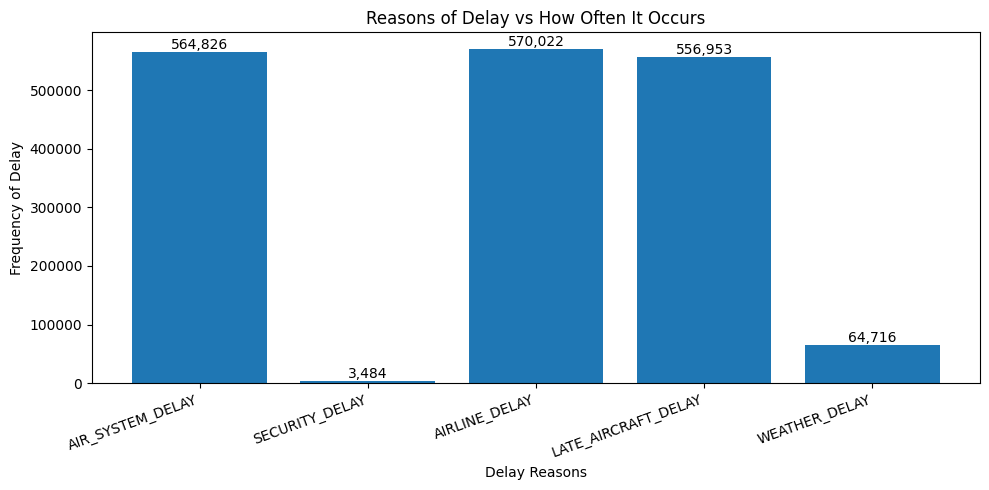

In [ ]:
# bar chart: reasons of delay vs frequency
# methodology:
# 1) set the delay columns into a list
# 2) filter to keep on "arrival delays" > 0 --> saved as a new df "delayed_flights"
# 3) Convert each delay column into T/F values (T: > 0) + sum "True" values to calculate frequency of each reason
# 4) Plot + adjust to look clean/proper

delay_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

delayed_flights = df[df['ARRIVAL_DELAY'] > 0]
frequency = (delayed_flights[delay_cols] > 0).sum()

plt.figure(figsize=(10, 5))
bars = plt.bar(frequency.index, frequency.values)
plt.xlabel('Delay Reasons')
plt.ylabel('Frequency of Delay')
plt.title('Reasons of Delay vs How Often It Occurs')

# rotate labels so they don't overlap
plt.xticks(rotation=20, ha='right')

# add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [ ]:
# bar chart: reasons of delay vs frequency
# methodology: